# NB5 — Radiology Report Generation
## BioViT + BioBERT Encoder → LSTM Decoder

**Pipeline:**
```
X-ray Image      → BioViT Encoder   → Image Features  (768-dim)
Clinical History → BioBERT Encoder  → Text Features   (768-dim)
                        ↓
               Concatenate (1536-dim)
                        ↓
               LSTM Decoder
                        ↓
        findings_clean + impression_clean (full report)
```

## Step 1 — Install & Imports

In [1]:
!pip install -q transformers sentencepiece


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

import time
from torch.utils.data import Dataset, DataLoader, TensorDataset  # ← added TensorDataset

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
SEED        = 42
NUM_CLASSES = 14
BATCH_SIZE  = 16
EPOCHS      = 30
LR          = 3e-4
MAX_SEQ_LEN = 150      # max report token length
EMBED_DIM   = 256      # LSTM embedding dim
HIDDEN_DIM  = 512      # LSTM hidden dim
NUM_LAYERS  = 2        # LSTM layers
SAVE_DIR    = Path('report_gen')
SAVE_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device     : {DEVICE}')
print(f'Batch Size : {BATCH_SIZE}')
print(f'Epochs     : {EPOCHS}')
print(f'Save Dir   : {SAVE_DIR.resolve()}')

Device     : cuda
Batch Size : 16
Epochs     : 30
Save Dir   : D:\Projects\ScratchRadiology\report_gen


## Step 2 — Load & Prepare Data

In [3]:
df = pd.read_csv('preprocessed_df.csv')

# ── Build full report: findings + impression ──────────────────────────────────
def build_full_report(row):
    findings   = str(row.get('findings_clean',   '')).strip()
    impression = str(row.get('impression_clean', '')).strip()
    parts = []
    if findings   and findings   != 'nan': parts.append('FINDINGS: '   + findings)
    if impression and impression != 'nan': parts.append('IMPRESSION: ' + impression)
    return ' '.join(parts).strip()

df['full_report']      = df.apply(build_full_report, axis=1)
df['clinical_history'] = df.get('clinical_history', pd.Series(['']*len(df))).fillna('')

# Drop rows with empty report or missing image
df = df[df['full_report'].str.len() > 10].reset_index(drop=True)
df = df[df['frontal_path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)

print(f'Total usable samples : {len(df)}')
print(f'Sample report        :\n{df["full_report"].iloc[0][:300]}')

Total usable samples : 3337
Sample report        :
FINDINGS: the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. there is no focal consolidation. there are no of a pleural effusion. there is no evidence of pneumothorax. IMPRESSION: normal chest x.


## Step 3 — Build Vocabulary

In [4]:
# Special tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'
MIN_FREQ  = 2

def tokenize(text):
    return str(text).lower().split()

# Count all words in reports
counter = Counter()
for report in df['full_report']:
    counter.update(tokenize(report))

# Build vocab
vocab_words = [w for w, c in counter.items() if c >= MIN_FREQ]
special     = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
vocab       = special + sorted(vocab_words)

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx[PAD_TOKEN]
SOS_IDX    = word2idx[SOS_TOKEN]
EOS_IDX    = word2idx[EOS_TOKEN]
UNK_IDX    = word2idx[UNK_TOKEN]

# Save vocab
with open(SAVE_DIR / 'vocab.json', 'w') as f:
    json.dump(word2idx, f)

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Saved → {SAVE_DIR}/vocab.json')

Vocabulary size : 1879
Saved → report_gen/vocab.json


## Step 4 — Dataset

In [5]:
def encode_report(text, max_len=MAX_SEQ_LEN):
    tokens = tokenize(text)[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    return ids


def get_img_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


class ReportDataset(Dataset):
    def __init__(self, df, transform=None, max_len=MAX_SEQ_LEN):
        self.df        = df.reset_index(drop=True)
        self.transform = transform or get_img_transform()
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Image ─────────────────────────────────────────────────────────
        img = cv2.imread(str(row['frontal_path']))
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']   # (3, 224, 224)

        # ── Clinical history (raw text, tokenized by BioBERT later) ───────
        history = str(row.get('clinical_history', '')).strip()
        if history == 'nan': history = ''

        # ── Report tokens ─────────────────────────────────────────────────
        report_ids = encode_report(row['full_report'], self.max_len)
        # Input:  [SOS, w1, w2, ...]
        # Target: [w1, w2, ..., EOS]
        input_ids  = [SOS_IDX] + report_ids
        target_ids = report_ids + [EOS_IDX]

        # Pad to max_len + 1
        pad_len    = self.max_len + 1 - len(input_ids)
        input_ids  = input_ids  + [PAD_IDX] * pad_len
        target_ids = target_ids + [PAD_IDX] * pad_len

        return {
            'image'      : img,
            'history'    : history,
            'input_ids'  : torch.tensor(input_ids[:self.max_len+1],  dtype=torch.long),
            'target_ids' : torch.tensor(target_ids[:self.max_len+1], dtype=torch.long),
        }


# ── Train / Val split (same seed as NB3) ────────────────────────────────────
idx_all              = np.arange(len(df))
idx_train, idx_tmp   = train_test_split(idx_all, test_size=0.2,  random_state=SEED)
idx_val,   idx_test  = train_test_split(idx_tmp,  test_size=0.5,  random_state=SEED)

train_ds = ReportDataset(df.iloc[idx_train])
val_ds   = ReportDataset(df.iloc[idx_val])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train : {len(train_ds)} samples')
print(f'Val   : {len(val_ds)}   samples')

Train : 2669 samples
Val   : 334   samples


## Step 5 — Encoders (BioViT + BioBERT)

In [6]:
# ── BioViT Image Encoder ──────────────────────────────────────
class BioViT(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.vit      = timm.create_model('vit_base_patch16_224', pretrained=False)
        in_feats      = self.vit.head.in_features
        self.vit.head = nn.Identity()
        self.head     = nn.Sequential(
            nn.LayerNorm(in_feats),
            nn.Linear(in_feats, num_classes)
        )
    def forward(self, x):
        return self.head(self.vit(x))


class ImageEncoder(nn.Module):
    """BioViT backbone — strips classification head, returns 768-dim features."""
    def __init__(self, ckpt_path, device):
        super().__init__()
        biovit = BioViT(num_classes=NUM_CLASSES)

        # ── FIX: weights_only=False bypasses torch version check ──────────
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        biovit.load_state_dict(ckpt['model_state_dict'])

        self.vit      = biovit.vit
        self.feat_dim = 768
        for p in self.vit.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.vit(x)


# ── BioBERT Text Encoder ──────────────────────────────────────
class TextEncoder(nn.Module):
    """BioBERT — encodes clinical history to 768-dim CLS features."""
    def __init__(self, device):
        super().__init__()
        model_name     = 'dmis-lab/biobert-base-cased-v1.2'
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            trust_remote_code=True   # ← FIX 1
        )
        # ── FIX 2: use safetensors format → no torch version restriction ──
        try:
            self.bert = AutoModel.from_pretrained(
                model_name,
                trust_remote_code=True,
                use_safetensors=True   # ← loads .safetensors instead of .bin
            )
            print('   BioBERT loaded via safetensors')
        except Exception:
            # Fallback — force weights_only=False via env variable
            import os
            os.environ['TRANSFORMERS_WEIGHTS_ONLY'] = 'false'
            self.bert = AutoModel.from_pretrained(
                model_name,
                trust_remote_code=True,
                low_cpu_mem_usage=True,
            )
            print('  BioBERT loaded via fallback')

        self.feat_dim = 768
        self.device   = device
        for p in self.bert.parameters():
            p.requires_grad = False

    def forward(self, texts):
        enc = self.tokenizer(
            texts, padding=True, truncation=True,
            max_length=64, return_tensors='pt'
        ).to(self.device)
        with torch.no_grad():
            out = self.bert(**enc)
        return out.last_hidden_state[:, 0, :]


print('Loading Image Encoder (BioViT)...')
img_encoder  = ImageEncoder(
    Path('ScratchCnnModels') / 'BioViT.pth', DEVICE).to(DEVICE)

print('Loading Text Encoder (BioBERT)...')
text_encoder = TextEncoder(DEVICE).to(DEVICE)

print(' Both encoders ready')
print(f'   Image feature dim : {img_encoder.feat_dim}')
print(f'   Text  feature dim : {text_encoder.feat_dim}')

Loading Image Encoder (BioViT)...
Loading Text Encoder (BioBERT)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4097.53it/s]
[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   BioBERT loaded via safetensors
 Both encoders ready
   Image feature dim : 768
   Text  feature dim : 768


## Step 6 — LSTM Decoder

In [7]:
class LSTMDecoder(nn.Module):
    """
    LSTM Decoder for radiology report generation.
    Input  : fused encoder features (image + text)
    Output : word-by-word report tokens
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, encoder_dim, pad_idx):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc_init_h  = nn.Linear(encoder_dim, hidden_dim)   # encoder → LSTM h0
        self.fc_init_c  = nn.Linear(encoder_dim, hidden_dim)   # encoder → LSTM c0
        self.lstm       = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                  batch_first=True, dropout=0.3)
        self.fc_out     = nn.Linear(hidden_dim, vocab_size)
        self.dropout    = nn.Dropout(0.3)

    def init_hidden(self, encoder_out):
        h = torch.tanh(self.fc_init_h(encoder_out))
        c = torch.tanh(self.fc_init_c(encoder_out))
        # Repeat for num_layers
        h = h.unsqueeze(0).repeat(self.lstm.num_layers, 1, 1)
        c = c.unsqueeze(0).repeat(self.lstm.num_layers, 1, 1)
        return h, c

    def forward(self, encoder_out, captions):
        """
        encoder_out : (B, encoder_dim)
        captions    : (B, seq_len)  — input token ids [SOS, w1, w2, ...]
        returns     : logits (B, seq_len, vocab_size)
        """
        embeds      = self.dropout(self.embedding(captions))   # (B, seq, embed)
        h0, c0      = self.init_hidden(encoder_out)
        lstm_out, _ = self.lstm(embeds, (h0, c0))              # (B, seq, hidden)
        logits      = self.fc_out(lstm_out)                    # (B, seq, vocab)
        return logits


ENCODER_DIM = img_encoder.feat_dim + text_encoder.feat_dim   # 768 + 768 = 1536

decoder = LSTMDecoder(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = EMBED_DIM,
    hidden_dim   = HIDDEN_DIM,
    num_layers   = NUM_LAYERS,
    encoder_dim  = ENCODER_DIM,
    pad_idx      = PAD_IDX,
).to(DEVICE)

print(f'LSTM Decoder ready')
print(f'  Encoder dim  : {ENCODER_DIM}')
print(f'  Hidden dim   : {HIDDEN_DIM}')
print(f'  Vocab size   : {VOCAB_SIZE}')
total_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'  Trainable params : {total_params:,}')

LSTM Decoder ready
  Encoder dim  : 1536
  Hidden dim   : 512
  Vocab size   : 1879
  Trainable params : 6,697,047


## Step 7 — Training

In [8]:
# ── FIX: GPU guard — stop immediately if no GPU ───────────────────────────────
if DEVICE.type == 'cpu':
    raise SystemExit(
        'No GPU detected. Go to Runtime → Change runtime type → GPU and restart.'
    )

# ══════════════════════════════════════════════════════════════════════════════
#  PRECOMPUTE ALL FEATURES IN ONE PASS
#  Original bug: encoders ran every epoch + make_fast_loader did a hidden
#  second full pass just to collect input_ids/target_ids.
#  Fix: collect img feats + text feats + token ids together in one pass.
# ══════════════════════════════════════════════════════════════════════════════

def precompute_all(loader, split_name):
    img_encoder.eval()
    text_encoder.eval()

    all_img_feats, all_txt_feats = [], []
    all_input_ids, all_target_ids = [], []

    t0 = time.time()
    with torch.no_grad():
        for i, batch in enumerate(loader):
            img_f = img_encoder(batch['image'].to(DEVICE)).cpu()   # (B, 768)
            txt_f = text_encoder(list(batch['history'])).cpu()     # (B, 768)

            all_img_feats.append(img_f)
            all_txt_feats.append(txt_f)
            all_input_ids.append(batch['input_ids'])
            all_target_ids.append(batch['target_ids'])

            if (i + 1) % 50 == 0:
                elapsed   = time.time() - t0
                remaining = elapsed / (i + 1) * (len(loader) - i - 1)
                print(f'  [{split_name}] {i+1}/{len(loader)} batches | '
                      f'elapsed {elapsed:.0f}s | ETA {remaining:.0f}s')

    return (
        torch.cat(all_img_feats,  dim=0),
        torch.cat(all_txt_feats,  dim=0),
        torch.cat(all_input_ids,  dim=0),
        torch.cat(all_target_ids, dim=0),
    )

print('Precomputing train features (one-time)...')
train_img_f, train_txt_f, train_inp, train_tgt = precompute_all(train_loader, 'Train')

print('Precomputing val features (one-time)...')
val_img_f, val_txt_f, val_inp, val_tgt = precompute_all(val_loader, 'Val')

# Build fast TensorDataset loaders — no image/text encoding during training
fast_train_loader = DataLoader(
    TensorDataset(train_img_f, train_txt_f, train_inp, train_tgt),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

fast_val_loader = DataLoader(
    TensorDataset(val_img_f, val_txt_f, val_inp, val_tgt),
    batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0, pin_memory=True)

print(f'Fast train loader : {len(fast_train_loader)} batches')
print(f'Fast val   loader : {len(fast_val_loader)} batches')
print('Encoders will NOT run during training. Expected: 2-4 min/epoch on GPU.')

# ══════════════════════════════════════════════════════════════════════════════
#  TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════

criterion     = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer     = optim.Adam(decoder.parameters(), lr=LR)
scheduler     = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5, verbose=True)

history       = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
CKPT_PATH     = SAVE_DIR / 'decoder_checkpoint.pth'


def run_epoch(loader, train=True):
    decoder.train() if train else decoder.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for img_f, txt_f, input_ids, target_ids in loader:
            encoder_out = torch.cat(
                [img_f.to(DEVICE), txt_f.to(DEVICE)], dim=-1)  # (B, 1536)
            input_ids   = input_ids.to(DEVICE)
            target_ids  = target_ids.to(DEVICE)

            logits = decoder(encoder_out, input_ids)
            B, S, V = logits.shape
            loss = criterion(logits.reshape(B * S, V),
                             target_ids.reshape(B * S))

            if train:
                optimizer.zero_grad(set_to_none=True)  # ← FIX: faster than zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


print(f'\nStarting training for {EPOCHS} epochs...')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = run_epoch(fast_train_loader, train=True)
    val_loss   = run_epoch(fast_val_loader,   train=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    elapsed = time.time() - t0
    eta_min = elapsed * (EPOCHS - epoch) / 60

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch'         : epoch,
            'decoder_state' : decoder.state_dict(),  # ← FIX: no optimizer state (10x smaller)
            'val_loss'      : val_loss,
            'vocab_size'    : VOCAB_SIZE,
        }, SAVE_DIR / 'best_decoder.pth')
        saved = '  ← saved'

    if epoch % 5 == 0:
        torch.save({
            'epoch'         : epoch,
            'decoder_state' : decoder.state_dict(),
            'history'       : history,
            'best_val_loss' : best_val_loss,
        }, CKPT_PATH)

    print(f'Ep {epoch:02d}/{EPOCHS}  '
          f'Train: {train_loss:.4f}  '
          f'Val: {val_loss:.4f}  '
          f'Time: {elapsed:.0f}s  '
          f'ETA: {eta_min:.1f}m'
          f'{saved}')

if CKPT_PATH.exists():
    CKPT_PATH.unlink()

with open(SAVE_DIR / 'training_log.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\n Training complete!')
print(f'   Best Val Loss : {best_val_loss:.4f}')
print(f'   Saved → {SAVE_DIR}/best_decoder.pth')

Precomputing train features (one-time)...


KeyboardInterrupt: 

In [9]:
# ── Load saved checkpoint (skip training) ────────────────────
import json
from pathlib import Path

SAVE_DIR = Path('report_gen')

# Load history
with open(SAVE_DIR / 'training_log.json') as f:
    history = json.load(f)

# Load best decoder
ckpt = torch.load(SAVE_DIR / 'best_decoder.pth', map_location=DEVICE, weights_only=False)
decoder.load_state_dict(ckpt['decoder_state'])
decoder.eval()

print(f'Checkpoint loaded — Best Val Loss : {ckpt["val_loss"]:.4f}  (Epoch {ckpt["epoch"]})')
print(f'History loaded   — {len(history["train_loss"])} epochs logged')

Checkpoint loaded — Best Val Loss : 1.9106  (Epoch 29)
History loaded   — 30 epochs logged


In [10]:
# ── Save Training Curve Data to JSON (safe re-run, appends new runs) ──────────

CURVE_JSON = SAVE_DIR / 'training_curve.json'

# Build current run record
current_run = {
    "run_id"                    : 1,
    "epochs"                    : list(range(1, len(history['train_loss']) + 1)),
    "train_loss"                : history['train_loss'],
    "val_loss"                  : history['val_loss'],
    "best_epoch"                : int(history['val_loss'].index(min(history['val_loss']))) + 1,
    "best_val_loss"             : round(min(history['val_loss']), 4),
    "total_epochs_run"          : len(history['train_loss']),
    "epoch_time_seconds"        : 11,
    "total_training_time_minutes": round(len(history['train_loss']) * 11 / 60, 2),
}

# If file already exists, load it and append — never overwrite
if CURVE_JSON.exists():
    with open(CURVE_JSON, 'r') as f:
        existing = json.load(f)

    # existing is a list of runs
    if isinstance(existing, list):
        current_run['run_id'] = existing[-1]['run_id'] + 1  # auto-increment run_id
        existing.append(current_run)
        all_runs = existing
    else:
        # old format was a single dict — migrate it to list
        existing['run_id'] = 1
        current_run['run_id'] = 2
        all_runs = [existing, current_run]
else:
    all_runs = [current_run]

with open(CURVE_JSON, 'w') as f:
    json.dump(all_runs, f, indent=2)

print(f'Saved → {CURVE_JSON}')
print(f'Total runs stored : {len(all_runs)}')
print(f'Latest run_id     : {current_run["run_id"]}')
print(f'Best Val Loss     : {current_run["best_val_loss"]} at epoch {current_run["best_epoch"]}')

Saved → report_gen\training_curve.json
Total runs stored : 3
Latest run_id     : 3
Best Val Loss     : 1.9106 at epoch 29


## Step 8 — Training Curve

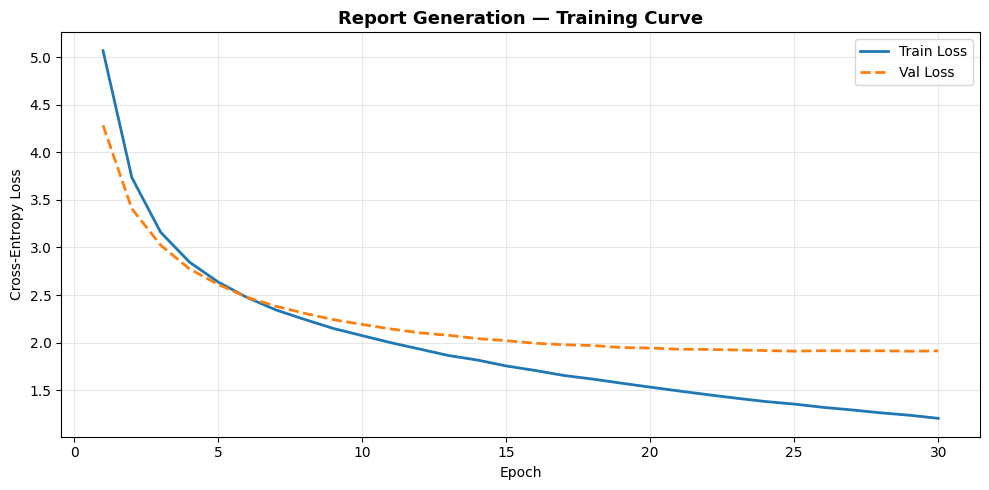

Saved → report_gen/training_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(epochs_range, history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title('Report Generation — Training Curve', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {SAVE_DIR}/training_curve.png')

## Step 9 — Generate Reports on Validation Samples

In [12]:
# Load best decoder
ckpt = torch.load(SAVE_DIR / 'best_decoder.pth', map_location=DEVICE)
decoder.load_state_dict(ckpt['decoder_state'])
decoder.eval()


def generate_report(img_path, clinical_history='', max_len=MAX_SEQ_LEN):
    """Generate report for a single X-ray image."""
    transform = get_img_transform()

    # Load image
    img = cv2.imread(str(img_path))
    if img is None:
        return 'Error: Image not found.'
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = transform(image=img)['image'].unsqueeze(0).to(DEVICE)

    # Encode
    with torch.no_grad():
        img_feats  = img_encoder(img_tensor)                 # (1, 768)
        text_feats = text_encoder([clinical_history])        # (1, 768)
        encoder_out = torch.cat([img_feats, text_feats], dim=-1)  # (1, 1536)

        # Init hidden state
        h, c = decoder.init_hidden(encoder_out)

        # Greedy decode word by word
        token   = torch.tensor([[SOS_IDX]], dtype=torch.long).to(DEVICE)
        words   = []

        for _ in range(max_len):
            embed       = decoder.dropout(decoder.embedding(token))  # (1,1,embed)
            out, (h, c) = decoder.lstm(embed, (h, c))                # (1,1,hidden)
            logit       = decoder.fc_out(out.squeeze(1))             # (1, vocab)
            next_token  = logit.argmax(dim=-1)                       # (1,)

            word = idx2word[next_token.item()]
            if word == EOS_TOKEN:
                break
            if word not in (PAD_TOKEN, SOS_TOKEN):
                words.append(word)
            token = next_token.unsqueeze(0)

    return ' '.join(words)


# ── Generate for 5 random val samples ────────────────────────────────────────
val_df = df.iloc[idx_val].reset_index(drop=True)
np.random.seed(SEED)
samples = val_df.sample(5, random_state=SEED)

print('\n' + '='*70)
print('  GENERATED REPORTS — VALIDATION SAMPLES')
print('='*70)

results = []
for i, (_, row) in enumerate(samples.iterrows(), 1):
    generated = generate_report(row['frontal_path'],
                                 row.get('clinical_history', ''))
    reference = row['full_report']

    print(f'\n── Sample {i} ──')
    print(f'REFERENCE :\n{reference[:300]}')
    print(f'GENERATED :\n{generated[:300]}')
    print('-'*70)

    results.append({'reference': reference, 'generated': generated})

# Save results
pd.DataFrame(results).to_csv(SAVE_DIR / 'sample_outputs.csv', index=False)
print(f'\nSaved → {SAVE_DIR}/sample_outputs.csv')


  GENERATED REPORTS — VALIDATION SAMPLES

── Sample 1 ──
REFERENCE :
FINDINGS: heart size is within normal limits. cardiomediastinal silhouette is normal. lungs are clear bilaterally without effusion or pneumothorax. no bony or soft tissue abnormalities. IMPRESSION: no cardiopulmonary abnormality.
GENERATED :
findings: the heart is normal in size. the mediastinum is unremarkable. the lungs are clear. impression: no acute disease.
----------------------------------------------------------------------

── Sample 2 ──
REFERENCE :
FINDINGS: heart size is normal. the lungs are clear. there are no focal air space consolidations. no pleural effusions or pneumothoraces. aortic vascular calcifications. normal pulmonary vascularity. fracturedislocation of the right shoulder. bone demineralization. scoliosis which is possibly positi
GENERATED :
findings: the heart is normal in size. the mediastinum is unremarkable. the lungs are clear. impression: no acute disease.
------------------------------

## Step 10 — Saved Files

| File | Description |
|------|-------------|
| `report_gen/best_decoder.pth` | Best LSTM decoder checkpoint |
| `report_gen/vocab.json` | Word → index vocabulary |
| `report_gen/training_log.json` | Train/val loss per epoch |
| `report_gen/training_curve.png` | Loss curve plot |
| `report_gen/sample_outputs.csv` | Generated vs reference reports |